In [1]:
import yfinance as yf

In [2]:
sp500 = yf.Ticker("^GSPC")

In [3]:
sp500 = sp500.history(period = 'max')

In [4]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-08 00:00:00-04:00,7440.569824,7466.810059,7395.129883,7405.729980,4898180000,0.0,0.0
2026-06-09 00:00:00-04:00,7438.660156,7483.149902,7237.850098,7386.649902,6006390000,0.0,0.0
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,0.0,0.0


In [5]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-06-01 00:00:00-04:00', '2026-06-02 00:00:00-04:00',
               '2026-06-03 00:00:00-04:00', '2026-06-04 00:00:00-04:00',
               '2026-06-05 00:00:00-04:00', '2026-06-08 00:00:00-04:00',
               '2026-06-09 00:00:00-04:00', '2026-06-10 00:00:00-04:00',
               '2026-06-11 00:00:00-04:00', '2026-06-12 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24729, freq=None)

<Axes: xlabel='Date'>

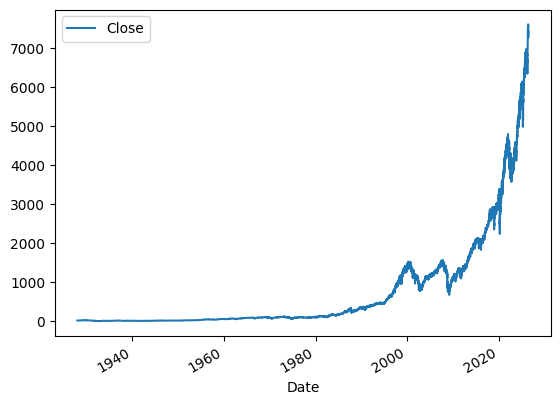

In [6]:
sp500.plot.line(y = 'Close', use_index = True)

In [7]:
del sp500['Dividends']
del sp500['Stock Splits']

In [8]:
sp500['Tomorrow'] = sp500['Close'].shift(-1)

In [9]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-06-08 00:00:00-04:00,7440.569824,7466.810059,7395.129883,7405.729980,4898180000,7386.649902
2026-06-09 00:00:00-04:00,7438.660156,7483.149902,7237.850098,7386.649902,6006390000,7266.990234
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805


In [10]:
sp500['Target'] = (sp500['Tomorrow'] > sp500['Close']).astype(int)

In [11]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-06-08 00:00:00-04:00,7440.569824,7466.810059,7395.129883,7405.729980,4898180000,7386.649902,0
2026-06-09 00:00:00-04:00,7438.660156,7483.149902,7237.850098,7386.649902,6006390000,7266.990234,0
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805,1


In [12]:
sp500 = sp500.loc['1990-01-01':].copy() # selecting the data only after 1990 so that there is no big shift in the data

In [13]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-06-08 00:00:00-04:00,7440.569824,7466.810059,7395.129883,7405.729980,4898180000,7386.649902,0
2026-06-09 00:00:00-04:00,7438.660156,7483.149902,7237.850098,7386.649902,6006390000,7266.990234,0
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805,1


In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100, min_samples_split = 100, random_state = 1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ['Close','Volume','Open','High','Low']
model.fit(train[predictors],train['Target'])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [18]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])



In [19]:
import pandas as pd
preds = pd.Series(preds, index = test.index)

In [20]:
preds

,0
Date,
2026-01-21 00:00:00-05:00,1
2026-01-22 00:00:00-05:00,1
2026-01-23 00:00:00-05:00,1
2026-01-26 00:00:00-05:00,0
2026-01-27 00:00:00-05:00,0
...,...
2026-06-08 00:00:00-04:00,0
2026-06-09 00:00:00-04:00,0
2026-06-10 00:00:00-04:00,0


In [22]:
precision_score(test['Target'],preds)

0.574468085106383

<Axes: xlabel='Date'>

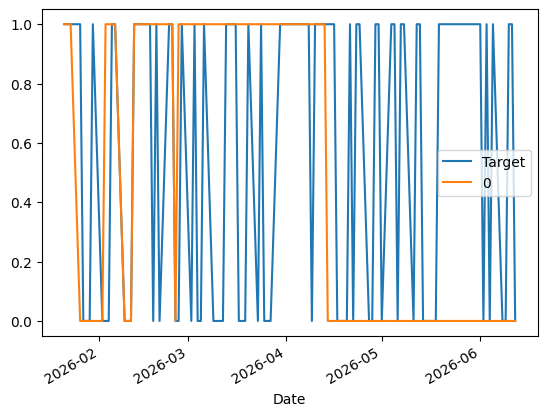

In [23]:
combined = pd.concat([test['Target'],preds],axis = 1)
combined.plot()

In [24]:
# Building A BackTesting System

In [26]:
def predict(train, test, predictors, model):
  model.fit(train[predictors],train['Target'])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds, index = test.index, name = 'Predictions')
  combined = pd.concat([test['Target'],preds],axis = 1)
  return combined

In [31]:
def backtest(data, model, predictors, start = 2500, step = 250):
  all_predictions = []

  for i in range(start, data.shape[0], step):
    train = data.iloc[0:i].copy()
    test = data.iloc[i:(i+step)].copy()
    predictions = predict(train, test, predictors, model)
    all_predictions.append(predictions)

  return pd.concat(all_predictions)

In [32]:
predictions = backtest(sp500, model, predictors)

In [34]:
precision_score(predictions['Target'],predictions['Predictions'])

0.5309701492537313

In [35]:
predictions['Target'].value_counts() / predictions.shape[0]

,count
Target,
1,0.537955
0,0.462045


In [36]:
#Adding Additional Predictors to the Model

In [37]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
  rolling_average = sp500.rolling(horizon).mean()

  ratio_column = f'Close_Ratio_{horizon}'
  sp500[ratio_column] = sp500['Close'] / rolling_average['Close']

  trend_column = f'Trend_{horizon}'
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target']

  new_predictors += [ratio_column, trend_column]

In [38]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-08 00:00:00-04:00,7440.569824,7466.810059,7395.129883,7405.729980,4898180000,7386.649902,0,1.001487,1.0,0.986451,3.0,1.046208,38.0,1.098536,144.0,1.398600,545.0
2026-06-09 00:00:00-04:00,7438.660156,7483.149902,7237.850098,7386.649902,6006390000,7266.990234,0,0.998710,1.0,0.989793,2.0,1.041663,38.0,1.094830,143.0,1.394039,545.0
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805,1,0.991834,0.0,0.981298,2.0,1.023423,37.0,1.076300,143.0,1.370543,545.0


In [39]:
sp500.dropna()

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05 00:00:00-04:00,7537.359863,7541.810059,7368.629883,7383.740234,5591290000,7405.729980,1,0.986600,1.0,0.978459,3.0,1.044906,37.0,1.096185,144.0,1.395371,544.0
2026-06-08 00:00:00-04:00,7440.569824,7466.810059,7395.129883,7405.729980,4898180000,7386.649902,0,1.001487,1.0,0.986451,3.0,1.046208,38.0,1.098536,144.0,1.398600,545.0
2026-06-09 00:00:00-04:00,7438.660156,7483.149902,7237.850098,7386.649902,6006390000,7266.990234,0,0.998710,1.0,0.989793,2.0,1.041663,38.0,1.094830,143.0,1.394039,545.0


In [40]:
#Improving the Model


In [41]:
model = RandomForestClassifier(n_estimators = 200, min_samples_split = 50, random_state = 1)

In [42]:
def predict(train, test, predictors, model):
  model.fit(train[predictors],train['Target'])
  preds = model.predict_proba(test[predictors])[:,1]
  preds[preds >= .6] = 1
  preds[preds < .6] = 0
  preds = pd.Series(preds, index = test.index, name = 'Predictions')
  combined = pd.concat([test['Target'],preds],axis = 1)
  return combined

In [43]:
predictions = backtest(sp500, model, new_predictors)

In [44]:
predictions['Predictions'].value_counts()

,count
Predictions,
0.0,5625
1.0,1054


In [45]:
precision_score(predictions['Target'], predictions['Predictions'])

0.5445920303605313

In [46]:
print(f"Precision Score: {precision_score(predictions['Target'], predictions['Predictions'])}")
print("\nPrediction Value Counts:")
display(predictions['Predictions'].value_counts())

Precision Score: 0.5445920303605313

Prediction Value Counts:


,count
Predictions,
0.0,5625
1.0,1054
